In [1]:
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt

In [4]:
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
import base64

In [5]:
import equinox as eqx
import gymnasium as gym
import jax
import jax.numpy as jnp
import jaxtyping as jtp
import paramax

from jax_mc_pilco.simulators.collect_data import collect_experience
from jax_mc_pilco.training.learning import rollout_training_loop, world_training_loop
from jax_mc_pilco.training.loss import batched_rollout_loss, imagine_trajectory_with_true_actions
from jax_mc_pilco.model_learning.flow_model import FlowDynamics

In [6]:
from jax_mc_pilco.training.training_utils import (
    count_fruitless,
    get_batches,
    train_val_split,
)

In [7]:
jax.config.update("jax_enable_x64", True)

In [12]:
2 ** int(jnp.log2(5_000))

4096

In [13]:
problem: str = "InvertedDoublePendulum-v5"
env = gym.make(problem)

key = jax.random.key(seed=4)
key, subkey = jax.random.split(key)
_, max_episode_len, states, actions, next_states, rewards = collect_experience(env, 5_000, subkey, None, use_sobol = True)
print(f"Environment data collection complete. Sampled {states.shape[0]} points.")

Environment data collection complete. Sampled 4096 points.


In [14]:
states.shape, actions.shape, next_states.shape

((4096, 64, 9), (4096, 64, 1), (4096, 64, 9))

In [15]:
init_states = states[:,0,:]

In [16]:
key_subkey = jax.random.split(key)
world_model_baseline = FlowDynamics(
    key=subkey,
    state_dim=states.shape[-1],
    action_dim=actions.shape[-1],
    state_low=states.min(axis=tuple(range(states.ndim - 1))),
    state_high=states.max(axis=tuple(range(states.ndim - 1))),
)
params, static = eqx.partition(
    world_model_baseline,
    eqx.is_inexact_array,
    is_leaf=lambda leaf: isinstance(leaf, paramax.NonTrainable),
)
key, subkey = jax.random.split(key)
print(batched_rollout_loss(params, static, subkey, init_states, next_states, actions,))

119.96613146447265


In [17]:
key, subkey = jax.random.split(key)
dynamics, d_losses = world_training_loop(subkey, states, actions)

print("Dynamics model fit complete. Final validation loss:", d_losses["val"][-1])

 20%|███████▊                               | 200/1000 [12:19<49:16,  3.70s/it, train=-5.61, val=-5.68 (Max patience reached)]

Dynamics model fit complete. Final validation loss: -5.676275619406557


Let's do some rollouts with this dynamics model using true starting states and true actions.  Then we can compare against the true states.

In [18]:
# What is the current rollout loss?
params, static = eqx.partition(
    dynamics,
    eqx.is_inexact_array,
    is_leaf=lambda leaf: isinstance(leaf, paramax.NonTrainable),
)
key_subkey = jax.random.split(key)
print(batched_rollout_loss(params, static, subkey, init_states, next_states, actions,))

110.57359056439289


In [ ]:
# Better but what if we train this loss specifically?
key, subkey = jax.random.split(key)
new_dynamics, losses = rollout_training_loop(subkey, states, next_states, actions)

  2%|█▏                                                             | 18/1000 [01:07<1:00:20,  3.69s/it, train=82.4, val=82.3]

In [16]:
# Check to see how this dynamics model is predicting

In [17]:
def trajectory_with_true_actions(
    world_model: FlowDynamics,
    key: jtp.Key[jtp.Array, ""],
    init_state: jax.Array,
    true_next_states: jax.Array,
    actions: jax.Array,
) -> jax.Array:
    """Rolls out the policy inside the world model with known actions."""

    init_hidden = jnp.zeros(world_model.memory.hidden_size)

    def step(carry: tuple, action: jax.Array) -> tuple[tuple[jax.Array, jax.Array, jax.Array], jax.Array]:
        state, hidden, key = carry
        # Move world model forward
        key, wm_key = jax.random.split(key)
        next_state, next_hidden = world_model.predict_next_state_and_hidden(
            wm_key,
            state,
            action,
            hidden,
        )

        return (next_state, next_hidden, key), next_state
    _, pred_next_states = jax.lax.scan(step, (init_state, init_hidden, key), actions)
    return pred_next_states

In [23]:
subkeys = jax.random.split(subkey, 1000)

In [25]:
pred_next_states = jax.vmap(trajectory_with_true_actions, in_axes=(None, 0, None, None, None))(new_dynamics, subkeys, init_states[0], next_states[0], actions[0])

In [27]:
pred_next_states.shape

(1000, 15, 9)

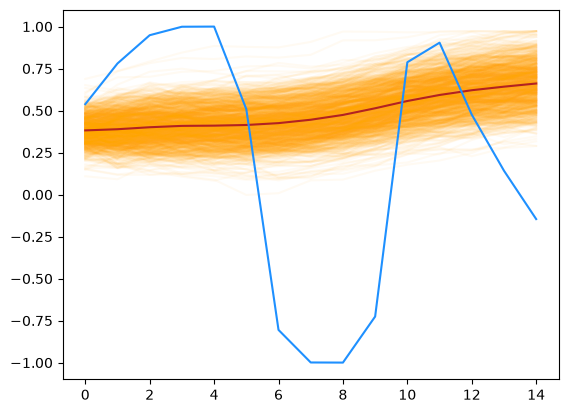

In [30]:
d = 2
for i in range(1000):
    plt.plot(pred_next_states[i,:,d], color='orange', alpha = 0.05);
plt.plot(pred_next_states[:,:,d].mean(axis=0), color='firebrick');
plt.plot(next_states[0,:,d], color='dodgerblue')

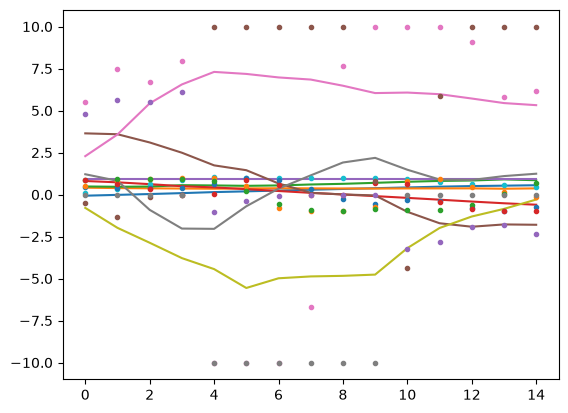

In [20]:
plt.plot(pred_next_states);
plt.plot(next_states[0], '.');